<a target="_blank" href="https://colab.research.google.com/github/LSSTC-DSFP/Session-25/blob/main/Day2/DeepLearningSolutions.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Deep Learning Problem Set

This notebook can be used in two ways:
1. If on the Rubin Science Platform, you can classify stars and galaxies
1. Otherwise, you can do a choose your own adventure classification

Either way, we'll use CNNs to do binary image classification. **Execute 1 of the next 2 cells.**


In [ ]:
# Option 1: Rubin Data
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

# ── Data path setup ───────────────────────────────────────────────────────────
TUTORIAL_USER = "amiller"
DATA_ROOT     = f"/home/{TUTORIAL_USER}/sg_tutorial_data"
CATALOG_PATH  = f"{DATA_ROOT}/catalog/dp1_labeled_with_cutouts.parquet"
CUTOUT_DIR    = f"{DATA_ROOT}/cutouts/"
MODELS_DIR    = f"{DATA_ROOT}/models/"

assert os.path.exists(CATALOG_PATH), \
    f"Cannot find catalog at {CATALOG_PATH} — did you set TUTORIAL_USER and join the group?"
assert os.path.exists(CUTOUT_DIR), \
    f"Cannot find cutouts at {CUTOUT_DIR}"

print("Data access confirmed ✓")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Load the catalog
df = pd.read_parquet(CATALOG_PATH)
df["objectId"] = df["objectId"].astype(np.int64)

print(f"Total sources: {len(df):,}")
print(f"\nLabel distribution:")
print(df["label"].value_counts().rename({0: "Galaxy (0)", 1: "Star (1)"}))
print(f"\nStar fraction: {df['label'].mean():.2%}")
print(f"\nColumns available:")
print(df.columns.tolist())

# Define our feature set
FEATURE_COLS = [
    "r_psfToCmodel",
    "i_psfToCmodel",
    "r_ixx", "r_iyy", "r_ixy",
    "i_ixx", "i_iyy", "i_ixy",
    "r_extendedness",
    "i_extendedness",
]

# Add colors
df["g_minus_r"] = (-2.5 * np.log10(df["g_psfFlux"] / df["r_psfFlux"]))
df["r_minus_i"] = (-2.5 * np.log10(df["r_psfFlux"] / df["i_psfFlux"]))
df["i_minus_z"] = (-2.5 * np.log10(df["i_psfFlux"] / df["z_psfFlux"]))
FEATURE_COLS += ["g_minus_r", "r_minus_i", "i_minus_z", "r_mag"]

# Drop rows with any NaN in features or label
df_clean = df[FEATURE_COLS + ["label", "objectId", "cutout_path"]].dropna().copy()

# Clip extreme outliers that will confuse the tree visualisation
for col in ["r_psfToCmodel", "i_psfToCmodel"]:
    df_clean[col] = df_clean[col].clip(0, 2)

# Dataset class for loading cutouts
class CutoutDataset(Dataset):
    def __init__(self, object_ids, labels, cutout_dir, transform=None):
        self.object_ids = object_ids
        self.labels = labels
        self.cutout_dir = cutout_dir
        self.transform = transform

    def __len__(self):
        return len(self.object_ids)

    def __getitem__(self, idx):
        obj_id = int(self.object_ids[idx])
        path = os.path.join(self.cutout_dir, f"{obj_id}.npy")
        img = np.load(path).astype(np.float32)

        # Arcsinh stretch — handles dynamic range gracefully
        # Normalise by a softplus of the image std to be robust to outliers
        scale = np.arcsinh(np.std(img) * 3 + 1e-6)
        img = np.arcsinh(img / (np.std(img) + 1e-6)) / (scale + 1e-6)

        # Add channel dimension: (H, W) -> (1, H, W)
        img = img[np.newaxis, :, :]

        if self.transform:
            img = self.transform(img)


        label = int(self.labels[idx])
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)


# Prepare image dataset — use same sources as tabular problems
df_img = df_clean.dropna(subset=["cutout_path"]).copy()
df_img = df_img[df_img["cutout_path"].apply(
    lambda p: os.path.exists(os.path.join(CUTOUT_DIR, f"{int(df_img.loc[df_img['cutout_path']==p, 'objectId'].values[0])}.npy"))
    if pd.notna(p) else False
)]

ids_all   = df_img["objectId"].values
y_img_all = df_img["label"].values

ids_train, ids_test, yi_train, yi_test = train_test_split(
    ids_all, y_img_all, test_size=0.2, random_state=42, stratify=y_img_all
)

train_dataset = CutoutDataset(ids_train, yi_train, CUTOUT_DIR)
test_dataset  = CutoutDataset(ids_test,  yi_test,  CUTOUT_DIR)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

In [1]:
# Option 2: Choose your own classification
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Options are:
# (0) Airplane, (1) Car, (2) Bird, (3) Cat, (4) Deer, (5) Dog, (6) Frog,
# (7) Horse, (8) Ship, (9) Truck.

# As a default, I've chosen Car vs. Horse. Pick your favorite two!
# The more similar the two classes are (e.g. cat vs dog is a little harder than
# car vs horse), the more involved your network will need to be.

# Map labels 1 (Car) and 7 (Horse) to 0 and 1 before creating the dataset
label_map = {1: 0, 7: 1}
target_transform = transforms.Lambda(lambda y: label_map[y] if y in label_map else y)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Apply the target_transform here
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform, target_transform=target_transform)
full_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform, target_transform=target_transform)

# Since labels are already transformed, we filter for 0 and 1
binary_indices_train = [i for i, (_, label) in enumerate(full_train_dataset) if label in (0, 1)]
binary_indices_test = [i for i, (_, label) in enumerate(full_test_dataset) if label in (0, 1)]

binary_train_dataset = Subset(full_train_dataset, binary_indices_train)
binary_test_dataset = Subset(full_test_dataset, binary_indices_test)

train_loader = DataLoader(binary_train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(binary_test_dataset, batch_size=5000, shuffle=False)

100%|██████████| 170M/170M [01:06<00:00, 2.55MB/s]


Now in either route, you should have two objects with the data you need:
- `train_loader`
- `test_loader`

These loaders contain images with dimensions (64x64x1) that are ready to be passed through CNNs.

## Problem 1

Build a CNN, train it on the training data, evaluate it on the testing data.

There are a lot of steps, so we'll go one at a time.

### Problem 1 - Step 1 of 4

Create a class that contains the architecture of your CNN.

Don't worry too much about which activation functions or the sizes of kernels. Remember, these are hyperparameters you can optimize later.

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1x64x64 -> 32x32x32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2: 32x32x32 -> 64x16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3: 64x16x16 -> 128x8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)


## Problem 1 - Step 2 of 4

Instantiate your cnn. Print it to verify things look reasonable to you.

In [3]:
cnn = SimpleCNN()
print(cnn)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=T

## Problem 1 - Step 3 of 4

Choose your optimizer and loss function.

Again, you can switch up the loss function, optimizer, and optimizer's learning rate when you tune it, so no need to worry about picking the best ones.

In [4]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.01)

## Problem 1 - Step 4 of 4

Build the training loop and train your model.

Configure it to output the loss every so often like this:

```python
for epoch in range(1, epochs + 1):
    cnn.train()
    for batch_idx, (data, target) in enumerate(train_loader):

      # <your training loop contents here>

      if batch_idx % 20 == 0:
          print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss_value.item():.6f}')
```

Bonus points if you evaluate the accuracy of the validation set at the end of each epoch. Revisit the lecture for examples here. Remember to set your model to `train()` or `eval()` depending on what operation you're doing.

In [5]:
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

for epoch in range(1, epochs + 1):
    cnn.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = cnn(data)
        loss_value = loss_fn(output, target)
        loss_value.backward()
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss_value.item():.6f}')

    cnn.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = cnn(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    print(f'\nAccuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.1f}%)\n')

Train Epoch: 1 [0/15000] Loss: 0.824193
Train Epoch: 1 [1280/15000] Loss: 0.877965
Train Epoch: 1 [2560/15000] Loss: 0.666625
Train Epoch: 1 [3840/15000] Loss: 0.539106
Train Epoch: 1 [5120/15000] Loss: 0.558357
Train Epoch: 1 [6400/15000] Loss: 0.541196
Train Epoch: 1 [7680/15000] Loss: 0.528567
Train Epoch: 1 [8960/15000] Loss: 0.497073
Train Epoch: 1 [10240/15000] Loss: 0.626542
Train Epoch: 1 [11520/15000] Loss: 0.380408
Train Epoch: 1 [12800/15000] Loss: 0.537217
Train Epoch: 1 [14080/15000] Loss: 0.494177

Accuracy: 2405/3000 (80.2%)

Train Epoch: 2 [0/15000] Loss: 0.433218
Train Epoch: 2 [1280/15000] Loss: 0.422019
Train Epoch: 2 [2560/15000] Loss: 0.529991
Train Epoch: 2 [3840/15000] Loss: 0.433078
Train Epoch: 2 [5120/15000] Loss: 0.454892
Train Epoch: 2 [6400/15000] Loss: 0.431619
Train Epoch: 2 [7680/15000] Loss: 0.385706
Train Epoch: 2 [8960/15000] Loss: 0.359936
Train Epoch: 2 [10240/15000] Loss: 0.389480
Train Epoch: 2 [11520/15000] Loss: 0.339029
Train Epoch: 2 [12800/15

## Problem 2

Did it work? If your training loop ran, skip down to Problem 3.

It definitely didn't work for me at first. The goal of this problem is to diagnose behaviors and learn what to change.

My guess is one or more of the things below happened. Try the recommendations, redo your training, and see if you can get a CNN to work.

#### Error messages about the sizes of layers not lining up

- Most commonly this happens in the first fully connected layers. Figure out how many features arise from your convolutional part. You may also find the expected size of the FC input in the error message.

#### Error messages in the evaluation of the loss function

- The loss function you chose either is not designed for a binary classification problem, or the data your `forward` function returns is not well-matched to the loss function. Experiment with different loss functions and final activation functions.

## Problem 3

Congrats on making it to the training loop! If your training loss overall decreases as you train, move on to Problem 4.

Now that things are running, there may be some new problems.

As a general rule of thumb, give the network 1.5-2 epochs before stopping execution and trying something new.

#### Training loss jumps around wildly

- If your loss fluctuates a little bit but overall decreases, that's normal.
- If the magnitude of the fluctuations approaches or exceeds ~10% of the loss, your learning rate is too large
- If it barely moves at all, your learning rate is too small.

#### No learning is happening
- The signature of this is the loss never really deviates from its starting value. Often this means your network is classifying everything as 1 class and is not able to learn.

  - For Stars vs. Galaxies, this will probably appear as an accuracy of 86%, since the dataset is roughly 86% galaxies
  - For the CIFAR10 dataset, this will probably appear as an accuracy of 50%

- This likely means your network isn't powerful enough or something isn't hooked up right. The next problem will address improving the network's classification power. Move on to that problem to see if those suggestions help, if they don't it's likely something isn't hooked up right.

## Problem 4

Time to attempt to improve the performance.

The simple CNNs we developed in the lecture had very easy datasets to operate on. Real images are another story, and typically require more advanced networks.

#### Improvement 1

Convolution blocks with batch normalization. This scales the images in the same batch to have the same mean and standard deviation. It makes it easier for weights to be learned for the whole dataset.

```python
self.block1 = nn.Sequential(
  # Block 1: 1x64x64 -> 32x32x32
  nn.Conv2d(1, 32, kernel_size=3, padding=1),
  nn.BatchNorm2d(32),
  nn.ReLU(inplace=True),
  nn.MaxPool2d(2),
)

def forward(self, x):
  x = self.block1(x)
  ...
```

#### Improvement 2

Adjust `kernel_size` and max pooling size. A rule of thumb is the kernel size (in units of pixels) should be about the size of human-recognizable features in the images.

#### Improvement 3

Try stacking convolutional blocks. To make the network stronger, go deeper!

```python
self.blocks = nn.Sequential(
    # Block 1: 1x64x64 -> 32x32x32
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),
    # Block 2: 32x32x32 -> 64x16x16
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),
    # Block 3: 64x16x16 -> 128x8x8
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),
)
```

#### Improvement 4

Add dropout in your fully-connected section. Dropout forces the network to ignore a fraction of the connections between nodes. This strategy prevents overfitting. If your network is stuck in a local minimum of the loss landscape, dropout can help you climb out of it.

```python
self.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(128 * 8 * 8, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(256, 2),  
)

def forward(self, x):
    return self.classifier(self.blocks(x)).squeeze(1)
```

## Problem 5

Thinking back to the SupervisedML lecture, plot a ROC curve and confusion matrix by applying your trained network to the test data.

Feel free to look back at the lecture / solutions to grab the scikit-learn funtions we used.

In [19]:
# Get predictions
cnn.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = cnn(data)
        y_pred += output.argmax(dim=1, keepdim=True).numpy()[:,0].tolist()
        y_true += target.numpy().tolist()



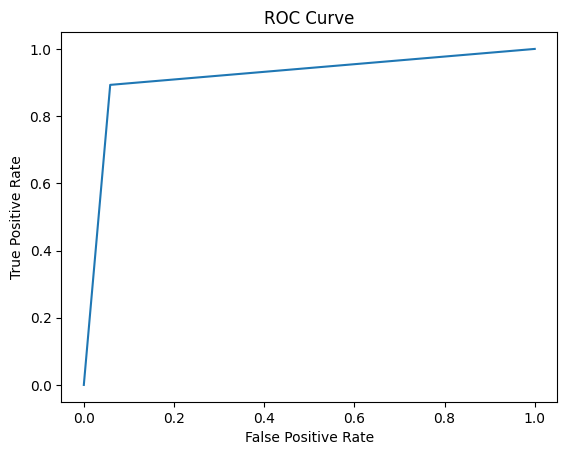

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      2000
           1       0.88      0.89      0.89      1000

    accuracy                           0.93      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000



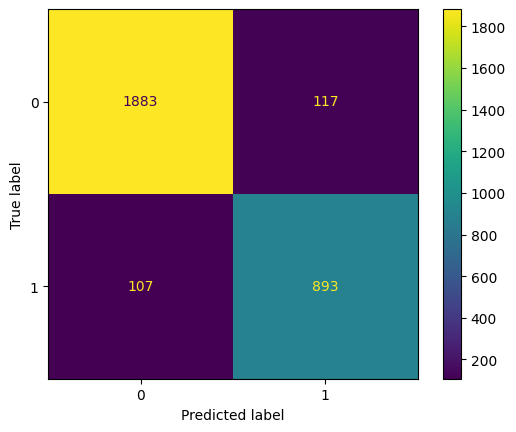

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_true, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
plt.show()

# Problem 6 (Challenge)

Visualize some of the images alongside their predicted label. Look at examples for TP, FP, TN, and FN. Do you notice any things that the correctly-classified images have in common that differentiates them from the incorrectly-classified images?

## Problem 7 (Challenge)

Build an AlexNNet and apply it to the data.

![](https://media.geeksforgeeks.org/wp-content/uploads/20230215094135/CNN-Architectures-2.png)

You'll need a couple tweaks since our images are (64x64x1) and we're doing a two-class problem instead of a 1,000-class problem.

- Your first fully connected layer will have a different number of inputs (4096) was a consequence of the image size interacting with the convolutional layers
- Your last fully connected layer will need to reduce down to 2 outputs
- After each convolutional layer, apply a ReLU activation function before doing the max pool operation.


## Problem 8 (Challenge, and getting fancy)

Implement, train, and evalutate a CNN that incorporates a naive-version Inception module.

![](https://media.geeksforgeeks.org/wp-content/uploads/20200429201304/Incepption-module.PNG)

There's a key difference between the inception block and what we've done so far. Previously, the `forward` function had one path - now there are multiple in parallel. Because PyTorch gives you full control of the architecture, you can do fun things like this.

Filter concatenation means stacking the outputs of the different blocks on top of each other using the "depth" dimension as opposed to "height" and "width."

If you're stuck, look up examples of using PyTorch to implement inception modules (there are plenty) and use that as a starting point.